In [12]:
import tensorflow as tf
import numpy as np
import pandas as pd

## For file operations
import os
import glob

## For image processing
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

from tensorflow.keras.optimizers import Adam
from tensorflow.keras import models, layers

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
##checking CUDA and detected devices

print("Total physical devices:", tf.config.list_physical_devices())
print("Is CUDA available:",tf.test.is_built_with_cuda())

Total physical devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Is CUDA available: True


### Approach #1 - Using Tensorflow ImageDataGenerator

In [3]:
train_path = '/home/prashant/Documents/ML-DL/Deeplearning/intel_image_classification/data/seg_train/seg_train'
test_path = '/home/prashant/Documents/ML-DL/Deeplearning/intel_image_classification/data/seg_test/seg_test'
validation_path = '/home/prashant/Documents/ML-DL/Deeplearning/intel_image_classification/data/seg_pred/seg_pred'

In [22]:
img_size = (150, 150)
batch_size = 32

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    # dtype=tf.float32
)

train_generator = train_datagen.flow_from_directory(
    "/home/prashant/Documents/ML-DL/Deeplearning/intel_image_classification/data/seg_train/seg_train",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"  # use 'categorical' for >2 classes
)

train_generator.classes[0]

Found 14034 images belonging to 6 classes.


np.int32(0)

In [23]:
# Data augmentation for training
val_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    # dtype=tf.float32
)

val_generator = val_datagen.flow_from_directory(
    "/home/prashant/Documents/ML-DL/Deeplearning/intel_image_classification/data/seg_test/seg_test",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"  # use 'categorical' for >2 classes
)

val_generator.classes[0]

Found 3000 images belonging to 6 classes.


np.int32(0)

In [6]:
X, y = next(train_generator)
X.shape, y.shape

((32, 150, 150, 3), (32,))

In [7]:
y

array([4., 5., 1., 5., 5., 0., 4., 0., 1., 3., 5., 1., 5., 5., 2., 5., 3.,
       1., 4., 2., 5., 2., 1., 1., 5., 2., 2., 5., 4., 2., 0., 0.],
      dtype=float32)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


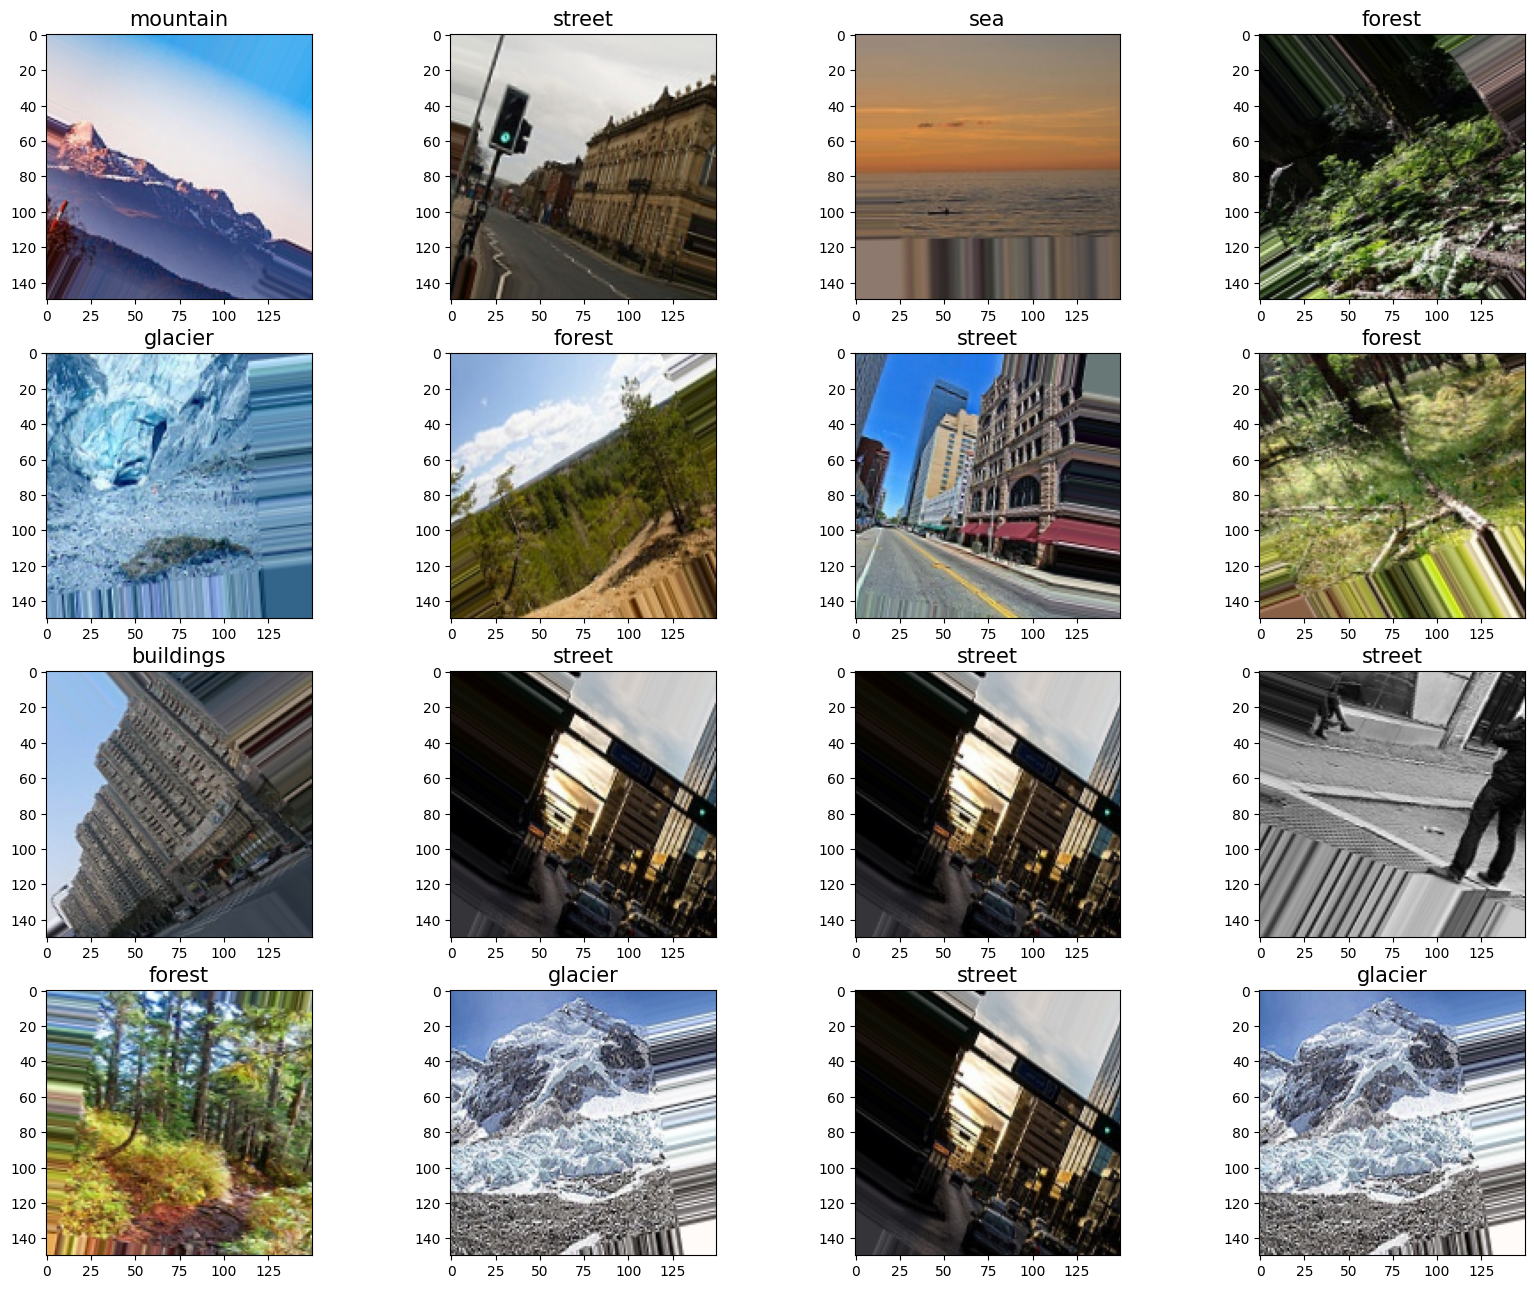

In [8]:
from matplotlib import pyplot as plt

classes = ['buildings','forest','glacier','mountain','sea','street']
print("Classes:", classes)

# let's print some data
plt.figure(figsize=(20, 20))

for i in range(0, len(X)):
    plt.subplot(5,4, i + 1)
    idx = np.random.randint(0,len(X))
    image = X[idx]
    plt.imshow(image)
    class_idx = int(y[idx])
    class_name = classes[class_idx]
    plt.title(class_name, color='k', fontsize=15)
    if i == 15:
        break

plt.show()


### Approach #2 - Using Tensorflow load_img & img_to_array

In [9]:
## Creating a DataFrame for train and test images to generate arrays later

def create_dataframe(path):
    image_path = glob.glob(path + '/*/*.jpg')
    labels = [os.path.basename(os.path.dirname(p)) for p in image_path]

    df = pd.DataFrame({
        'img_path': image_path,
        'label': labels
    })

    return df

train_df = create_dataframe(train_path)
test_df = create_dataframe(test_path)

print("Training data:",train_df.shape)
display(train_df.head())
print("Test data:", test_df.shape)
display(test_df.head()) 

Training data: (14034, 2)


,img_path,label
0,/home/prashant/Documents/ML-DL/Deeplearning/in...,forest
1,/home/prashant/Documents/ML-DL/Deeplearning/in...,forest
2,/home/prashant/Documents/ML-DL/Deeplearning/in...,forest
3,/home/prashant/Documents/ML-DL/Deeplearning/in...,forest
4,/home/prashant/Documents/ML-DL/Deeplearning/in...,forest


Test data: (3000, 2)


,img_path,label
0,/home/prashant/Documents/ML-DL/Deeplearning/in...,forest
1,/home/prashant/Documents/ML-DL/Deeplearning/in...,forest
2,/home/prashant/Documents/ML-DL/Deeplearning/in...,forest
3,/home/prashant/Documents/ML-DL/Deeplearning/in...,forest
4,/home/prashant/Documents/ML-DL/Deeplearning/in...,forest


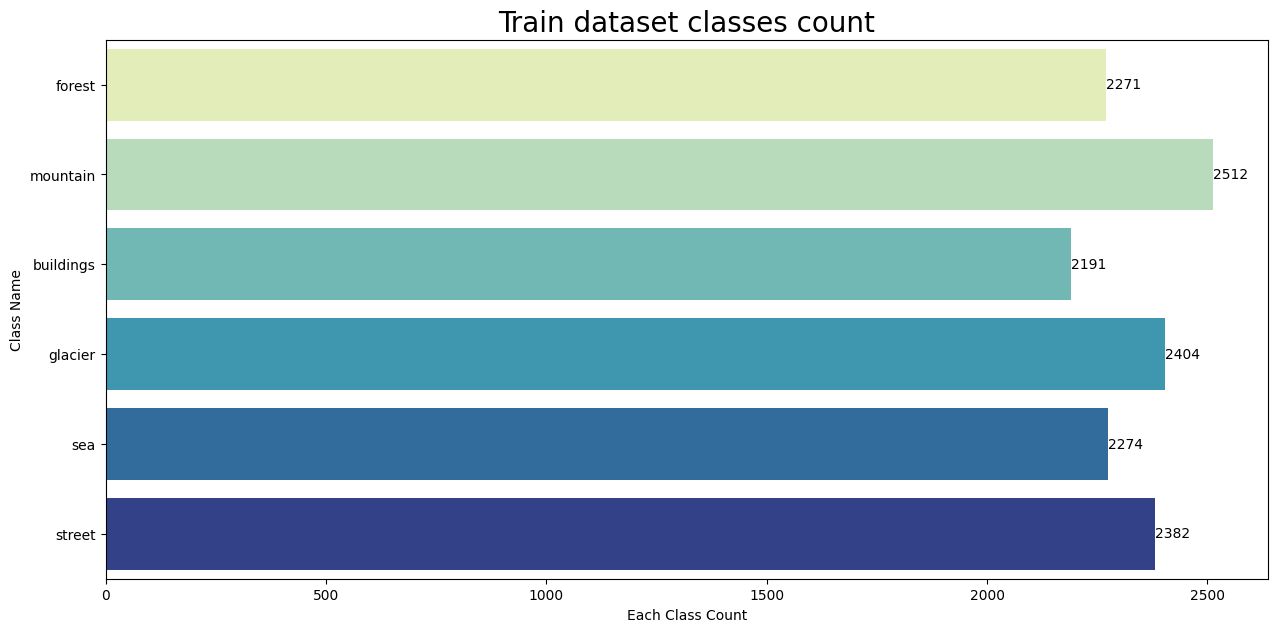

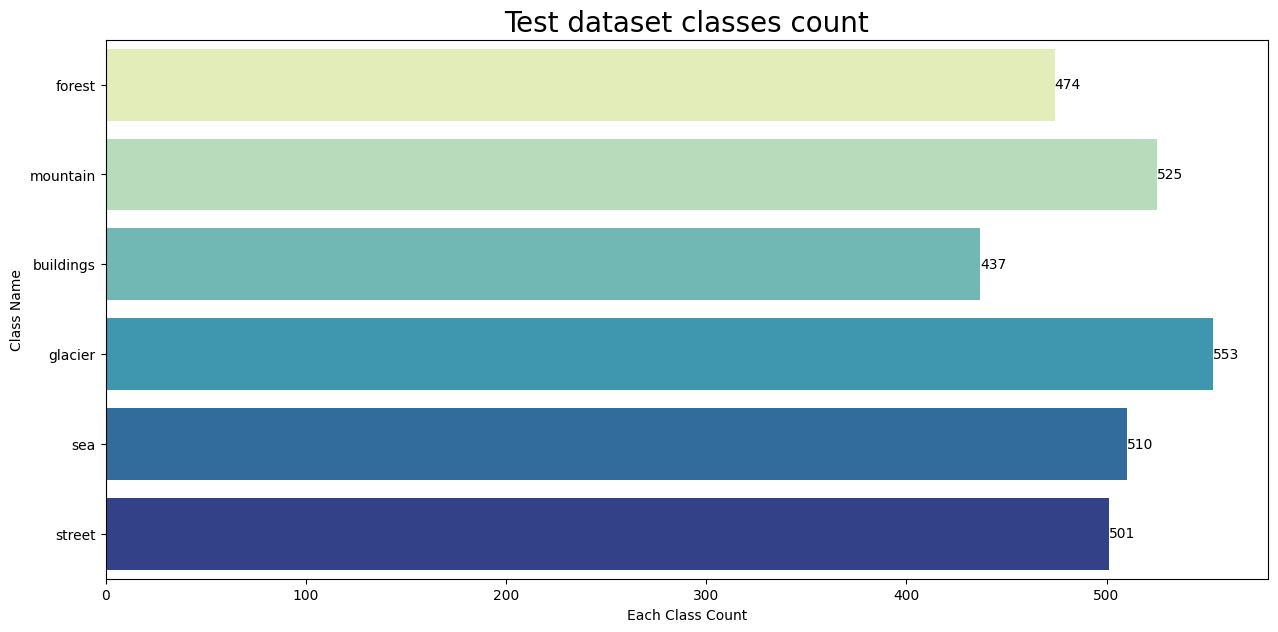

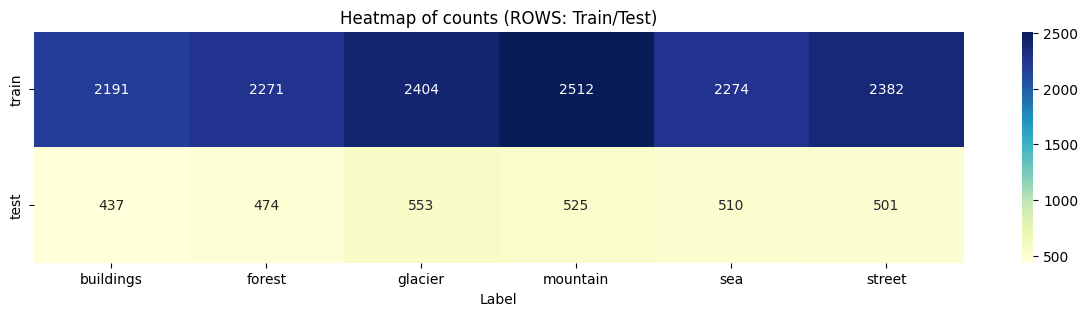

In [10]:
import seaborn as sns

def plot_class_distribution(dataframe,dataset_name):
    plt.figure(figsize=(15,7))
    ax = sns.countplot(data=dataframe , y=dataframe['label'], palette="YlGnBu")

    plt.xlabel('Each Class Count')
    plt.ylabel('Class Name')
    plt.title(f'{dataset_name} dataset classes count', fontsize=20)
    for i in range(len(dataframe['label'].value_counts())):
        ax.bar_label(ax.containers[i])

    plt.show()

plot_class_distribution(train_df, dataset_name='Train')
plot_class_distribution(test_df, dataset_name='Test')

## Combining data to visualize the Train/Test Distribution
counts = pd.DataFrame({
'train': train_df['label'].value_counts(),
'test':  test_df['label'].value_counts()
}).fillna(0).astype(int).sort_index()

# Heatmap (rows: train/test, columns: labels)
plt.figure(figsize=(15,3))
sns.heatmap(counts.T, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap of counts (ROWS: Train/Test)')
plt.xlabel('Label')
plt.show()

In [11]:
def prepare_img_data(dataset):

    img_arr = []
    class_labels = []

    TARGET_SIZE = (150, 150)

    for idx, row in dataset.iterrows():
        img = load_img(row['img_path'], target_size=TARGET_SIZE)
        img = img_to_array(img) / 255.0
        img_arr.append(img)
        if row['label'] == 'buildings':
            class_labels.append(0)
        elif row['label'] == 'forest':
            class_labels.append(1)
        elif row['label'] == 'glacier':
            class_labels.append(2)
        elif row['label'] == 'mountain':
            class_labels.append(3)
        elif row['label'] == 'sea':
            class_labels.append(4)
        else:
            class_labels.append(5)
    
    return np.array(img_arr), np.array(class_labels)

X_train, y_train = prepare_img_data(train_df)
print('Training data shape:', X_train.shape, y_train.shape)
X_test, y_test = prepare_img_data(test_df)
print('Test data shape:', X_test.shape, y_test.shape)

Training data shape: (14034, 150, 150, 3) (14034,)
Test data shape: (3000, 150, 150, 3) (3000,)


In [14]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax')
])

cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_cnn = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

2025-12-31 05:24:25.396233: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 3789180000 exceeds 10% of free system memory.
2025-12-31 05:24:28.725679: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 3789180000 exceeds 10% of free system memory.


Epoch 1/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.8322 - loss: 0.4749 - val_accuracy: 0.8233 - val_loss: 0.4939
Epoch 2/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8402 - loss: 0.4594 - val_accuracy: 0.8313 - val_loss: 0.4797
Epoch 3/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8476 - loss: 0.4344 - val_accuracy: 0.8257 - val_loss: 0.4813
Epoch 4/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8582 - loss: 0.4046 - val_accuracy: 0.8323 - val_loss: 0.4785
Epoch 5/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8692 - loss: 0.3758 - val_accuracy: 0.8337 - val_loss: 0.4767
Epoch 6/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8717 - loss: 0.3624 - val_accuracy: 0.8367 - val_loss: 0.4555
Epoch 7/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8806 - loss: 0.3454 - val_accuracy: 0.8233 - val_loss: 0.5186
Epoch 8/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8874 - loss: 0.3244 - 

In [25]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=img_size + (3,)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(512, activation="relu"),
    layers.Dense(6, activation="softmax")   # for binary; use Dense(num_classes, 'softmax') for multi-class
])

model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 44s 96ms/step - accuracy: 0.5624 - loss: 1.1434 - val_accuracy: 0.6400 - val_loss: 0.9533
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 41s 94ms/step - accuracy: 0.6622 - loss: 0.8907 - val_accuracy: 0.6827 - val_loss: 0.8328
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 42s 96ms/step - accuracy: 0.6997 - loss: 0.8017 - val_accuracy: 0.7387 - val_loss: 0.7263
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 42s 95ms/step - accuracy: 0.7307 - loss: 0.7345 - val_accuracy: 0.7327 - val_loss: 0.7294
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 42s 95ms/step - accuracy: 0.7485 - loss: 0.6845 - val_accuracy: 0.7570 - val_loss: 0.6658
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 41s 93ms/step - accuracy: 0.7605 - loss: 0.6601 - val_accuracy: 0.7817 - val_loss: 0.6221
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 42s 95ms/step - accuracy: 0.7726 - loss: 0.6227 - val_accuracy: 0.7717 - val_loss: 0.6084
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 42s 95ms/step - accuracy: 0.7795 - loss: 0.6107 - 